In [4]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

C:\Users\manoj\PycharmProjects\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

model = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

In [6]:
class ChatState(MessagesState):
    summary: str

In [7]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [8]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [9]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [10]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [11]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

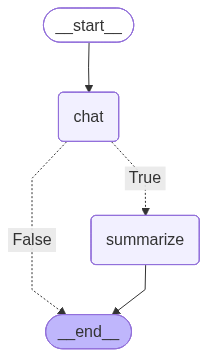

In [12]:
graph

In [13]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [14]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [15]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='2ddda0f4-9e1b-41df-b8f0-9b39ed6ac915')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : [{'type': 'text', 'text': 'Quantum physics (also known as quantum mechanics) is the branch of science that describes how the universe works at the smallest levels—atoms and subatomic particles like electrons, protons, and photons.\n\nAt this scale, the laws of "classical" physics (like Newton’s laws) break down. Instead of predictable paths and solid objects, we find a world of probability, waves, and "spooky" connections.\n\nHere is a breakdown of the core concepts that make quantum physics so fascinating and strange:\n\n---\n\n### 1. Quantization: The "Packets" of Energy\nIn our everyday world, things seem continuous (like a ramp). In the quantum world, things are "quantized" (like a staircase). Energy isn\'t a smooth flow; it comes in discrete little bundles c

In [16]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='2ddda0f4-9e1b-41df-b8f0-9b39ed6ac915'), AIMessage(content=[{'type': 'text', 'text': 'Quantum physics (also known as quantum mechanics) is the branch of science that describes how the universe works at the smallest levels—atoms and subatomic particles like electrons, protons, and photons.\n\nAt this scale, the laws of "classical" physics (like Newton’s laws) break down. Instead of predictable paths and solid objects, we find a world of probability, waves, and "spooky" connections.\n\nHere is a breakdown of the core concepts that make quantum physics so fascinating and strange:\n\n---\n\n### 1. Quantization: The "Packets" of Energy\nIn our everyday world, things seem continuous (like a ramp). In the quantum world, things are "quantized" (like a staircase). Energy isn\'t a smooth flow; it comes in discrete little bundles called **quanta**.\n*   **Example:** Light is made of individual packets of energ

In [ ]:
run_turn('What are some of Einstien"s fampus work')
show_state()

In [ ]:
run_turn('Explain special theory of relativity')
show_state()